In [ ]:
# Install required packages (run once)
!pip install networkx matplotlib numpy -q

# A Story That Becomes Data

Imagine your first week at university. You meet **Alice** during orientation and **Charlie** in class. Alice later introduces you to **Bob**, who in turn knows **David**. Meanwhile Charlie knows Eve.
At first this is just a story, five people, a handful of introductions.



But as a data scientist, you start asking structural questions. Who is most connected? Who acts as a bridge between groups? Can you reach David without going through Alice? If Alice leaves the university, does the network stay connected?

![Graph Image](https://raw.githubusercontent.com/ffalam/CMSC320TextBook/refs/heads/main/chapter21/graph1.png)

To answer these, we need to convert the story into a formal structure: **a graph**.



## What is a Graph?

A **graph** is a structure that represents:

- **Nodes (Vertices):** entities (people, cities, users)
- **Edges:** relationships (friendship, roads, links)

> Key Idea: Graph = Data + Relationships


### Definition

A **graph** is a mathematical structure:

$$G = (V, E)$$

| Symbol | Meaning | Example |
|--------|---------|--------|
| V | Set of **vertices** (nodes) | {You, Alice, Bob, Charlie, David, Eve} |
| E | Set of **edges** (connections) | {(You, Alice), (Alice, Bob), ...} |

### Types of Graphs

| Type | Description | Example |
|------|-------------|--------|
| **Undirected** | Edges have no direction; mutual relationship | Friendship network |
| **Directed (Digraph)** | Edges have direction (A→B ≠ B→A) | Twitter follows, web links |
| **Weighted** | Each edge carries a numeric value | Road distances, transaction amounts |
| **Bipartite** | Nodes split into two groups; edges only between groups | Users ↔ Movies |
| **Multigraph** | Multiple edges allowed between same pair | Multiple flights between two cities |

### Key Terminology

| Term            | Definition                                         | Example                                                                 |
|-----------------|----------------------------------------------------|-------------------------------------------------------------------------|
| Degree          | Number of edges connected to a node               | Alice has degree 3 (connected to You, Bob, Charlie)                     |
| Path            | A sequence of nodes connected by edges            | You → Alice → Bob → David                                               |
| Shortest Path   | The path with fewest hops (or lowest weight)      | The path of length 3 above is the only way to reach David               |
| Cycle           | A path that starts and ends at the same node      | You → Alice → Charlie → You                                             |
| Connected       | Every node can reach every other node             | Our university graph is connected                                       |
| Component       | A maximal connected subgraph                      | Disconnecting Alice would create two components                         |
---



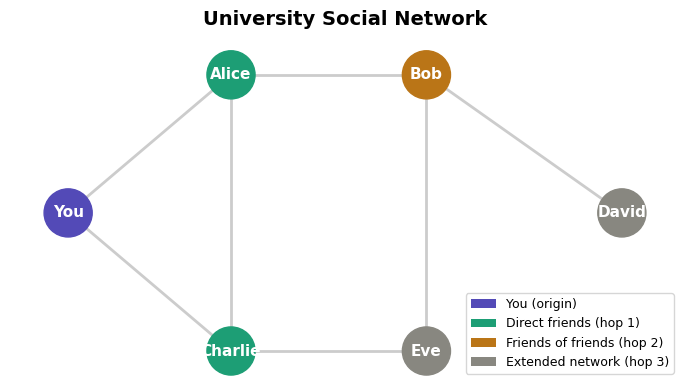

Nodes : 6
Edges : 7
Density: 0.467


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# Consistent figure style
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── Build the university social graph ──────────────────────────────────────
G = nx.Graph()

nodes = ['You', 'Alice', 'Bob', 'Charlie', 'David', 'Eve']
edges = [
    ('You', 'Alice'),
    ('You', 'Charlie'),
    ('Alice', 'Bob'),
    ('Alice', 'Charlie'),
    ('Bob', 'David'),
    ('Bob', 'Eve'),
    ('Charlie', 'Eve'),
]

G.add_nodes_from(nodes)
G.add_edges_from(edges)

# ── Node colours by distance from 'You' ────────────────────────────────────
color_map = {
    'You':     '#534AB7',
    'Alice':   '#1D9E75',
    'Charlie': '#1D9E75',
    'Bob':     '#BA7517',
    'David':   '#888780',
    'Eve':     '#888780',
}
node_colors = [color_map[n] for n in G.nodes()]

pos = {
    'You':     (0,   1),
    'Alice':   (1,   2),
    'Charlie': (1,   0),
    'Bob':     (2.2, 2),
    'Eve':     (2.2, 0),
    'David':   (3.4, 1),
}

fig, ax = plt.subplots(figsize=(7, 4))
nx.draw_networkx(
    G, pos, ax=ax,
    node_color=node_colors, node_size=1200,
    font_color='white', font_weight='bold', font_size=11,
    edge_color='#cccccc', width=2,
)

legend_elements = [
    mpatches.Patch(facecolor='#534AB7', label='You (origin)'),
    mpatches.Patch(facecolor='#1D9E75', label='Direct friends (hop 1)'),
    mpatches.Patch(facecolor='#BA7517', label='Friends of friends (hop 2)'),
    mpatches.Patch(facecolor='#888780', label='Extended network (hop 3)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_title('University Social Network', fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")
print(f"Density: {nx.density(G):.3f}")

## Applications of Graphs

Graphs are not just academic; they power real-world systems:

- **Navigation (Google Maps):** Road networks are weighted directed graphs: nodes are intersections, edges are road segments, weights are travel times that update in real time from GPS data. Dijkstra and A* (which uses geographic distance as a heuristic to guide search) find your route. The challenge is scale: the US road network has ~50 million nodes.
> Nodes → locations, Edges → roads (Used for shortest path).  
- **Social Networks:** Facebook's social graph had ~3 billion nodes at last public reporting. It powers friend recommendations (who shares many mutual friends with you?), feed ranking, and ad targeting. The graph is stored in a custom distributed system called TAO.
> Nodes → users, Edges → connections  (Used for recommendations).

- **Recommendation Systems:** Graphs like "Bipartite" (where every edge connects a vertex from one set to a vertex from the other set.) connect users to items they've interacted with. Collaborative filtering (we will discuss this in *later chapter*) asks: which items are connected to users similar to you? More sophisticated approaches use graph neural networks that propagate information through multi-hop neighborhoods.
Web search and PageRank

> Nodes → users + products,Edges → interactions  
- **Web Search:** The web is a directed graph with ~60 trillion pages. PageRank assigns each page a score equal to the sum of PageRank scores of pages linking to it, divided by their out-degree — a recursive definition solved as an eigenvector computation. Pages cited by authoritative pages inherit authority.
>Nodes → webpages, Edges → hyperlinks  

- **Biology and medicine:** Protein-protein interaction networks reveal which proteins work together. Metabolic networks model how cells convert nutrients to energy. Drug repurposing finds new uses for existing drugs by identifying proteins structurally close to a disease target in the interaction graph. Graph neural networks now power breakthrough protein structure prediction tools.

- **Fraud detection**: Financial transaction graphs detect anomalous patterns — cycles of transactions that suggest money laundering, or suspicious clustering of accounts. Graph-based features dramatically outperform purely tabular approaches for this problem.



| Domain | Nodes | Edges | Algorithm used |
|--------|-------|-------|----------------|
| **Navigation** (Google Maps) | Intersections | Roads | Dijkstra / A* |
| **Social Networks** (Facebook) | Users | Friendships | Community detection, BFS |
| **Recommendations** (Netflix) | Users + Movies | Ratings/views | Collaborative filtering, GNN |
| **Web Search** (Google) | Web pages | Hyperlinks | PageRank |
| **Biology** | Proteins | Interactions | Centrality, clustering |
| **Fraud Detection** | Accounts | Transactions | Anomaly detection |
| **Supply Chain** | Warehouses/ports | Routes | Min-cost flow |

## Graph Processing

Once we build a graph, we analyze it.

### Common Tasks:
- **Traversal (BFS, DFS)**: Systematically explore all nodes and edges in a graph.
- **Shortest Path**: Find the minimum-cost route between two nodes.
- **Community Detection**: Identify groups of densely connected nodes.
- **Ranking nodes**: Measure and rank node importance based on structure
- **Link prediction**: Predict likely future or missing connections between nodes.

> Insight: Graph processing = turning connections into decisions

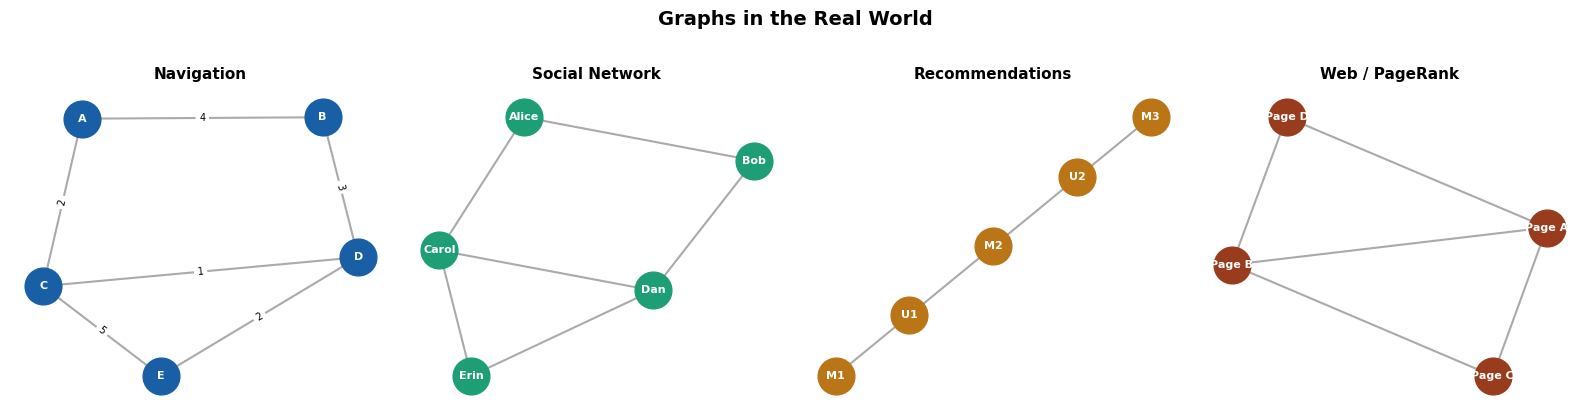

In [ ]:
# ── Visualise four application domains side by side ─────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Graphs in the Real World', fontsize=14, fontweight='bold', y=1.02)

configs = [
    {
        'title': 'Navigation',
        'nodes': ['A','B','C','D','E'],
        'edges': [('A','B',4),('A','C',2),('B','D',3),('C','D',1),('C','E',5),('D','E',2)],
        'color': '#185FA5',
        'weighted': True,
    },
    {
        'title': 'Social Network',
        'nodes': ['Alice','Bob','Carol','Dan','Erin'],
        'edges': [('Alice','Bob'),('Alice','Carol'),('Bob','Dan'),('Carol','Dan'),('Dan','Erin'),('Carol','Erin')],
        'color': '#1D9E75',
        'weighted': False,
    },
    {
        'title': 'Recommendations',
        'nodes': ['U1','U2','M1','M2','M3'],
        'edges': [('U1','M1'),('U1','M2'),('U2','M2'),('U2','M3')],
        'color': '#BA7517',
        'weighted': False,
    },
    {
        'title': 'Web / PageRank',
        'nodes': ['Page A','Page B','Page C','Page D'],
        'edges': [('Page A','Page B'),('Page B','Page C'),('Page C','Page A'),('Page D','Page B'),('Page A','Page D')],
        'color': '#993C1D',
        'weighted': False,
    },
]

for ax, cfg in zip(axes, configs):
    if cfg['weighted']:
        Gi = nx.Graph()
        Gi.add_nodes_from(cfg['nodes'])
        for u, v, w in cfg['edges']:
            Gi.add_edge(u, v, weight=w)
    else:
        Gi = nx.Graph()
        Gi.add_nodes_from(cfg['nodes'])
        Gi.add_edges_from(cfg['edges'])

    pos_i = nx.spring_layout(Gi, seed=42)
    nx.draw_networkx(
        Gi, pos_i, ax=ax,
        node_color=cfg['color'], node_size=700,
        font_color='white', font_size=8, font_weight='bold',
        edge_color='#aaaaaa', width=1.5,
        arrows=('Page' in cfg['nodes'][0]),
    )
    if cfg['weighted']:
        labels = nx.get_edge_attributes(Gi, 'weight')
        nx.draw_networkx_edge_labels(Gi, pos_i, edge_labels=labels, ax=ax, font_size=7)
    ax.set_title(cfg['title'], fontsize=11, fontweight='bold', pad=8)
    ax.axis('off')

plt.tight_layout()
plt.show()